# Customer Churn Prediction Models

In this notebook, we'll build machine learning models to predict customer churn based on the cleaned Indian Bank dataset. We'll use Logistic Regression and Random Forest models, evaluate their performance, and extract feature importance.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, classification_report

sns.set_theme(style="whitegrid")

## 1. Load Cleaned Data

In [2]:
df = pd.read_csv('../data/cleaned_indian_bank_churn.csv')
print(f"Data loaded with {len(df)} rows.")
df.head()

Data loaded with 10000 rows.


,CustomerID,Gender,Location,Age,Tenure,Balance,NumOfProducts,HasCreditCard,IsActiveMember,EstimatedSalary,Churn
0,10001,Male,Hyderabad,18.000000,1,71993.87,2,1,1,82042.759023,0
1,10002,Male,Chennai,48.048275,2,52803.26,2,1,1,51977.220605,0
2,10003,Female,Delhi,45.131104,9,0.00,1,1,1,64878.930001,0
3,10004,Female,Kolkata,59.352099,8,59252.24,2,0,0,80098.670584,1
4,10005,Male,Bangalore,63.327650,2,59554.13,2,1,1,80094.541212,0


## 2. Feature Engineering & Preprocessing
We will exclude `CustomerID` and prepare our feature matrix `X` and target vector `y`.

In [3]:
X = df.drop(columns=['CustomerID', 'Churn'])
y = df['Churn']

# Define categorical and numerical columns
categorical_cols = ['Gender', 'Location']
numerical_cols = ['Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCreditCard', 'IsActiveMember', 'EstimatedSalary']

# Create a preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_cols)
    ])

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")

Training set size: 8000
Test set size: 2000


## 3. Model Training & Evaluation function

In [4]:
def evaluate_model(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    print(f"--- {model_name} Performance ---")
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}")
    print(f"F1 Score:  {f1:.4f}")
    print("\nConfusion Matrix:")
    
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'{model_name} Confusion Matrix')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show()
    
    return {'Model': model_name, 'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1': f1}

## 4. Logistic Regression

--- Logistic Regression Performance ---
Accuracy:  0.8350
Precision: 0.5294
Recall:    0.0272
F1 Score:  0.0517

Confusion Matrix:


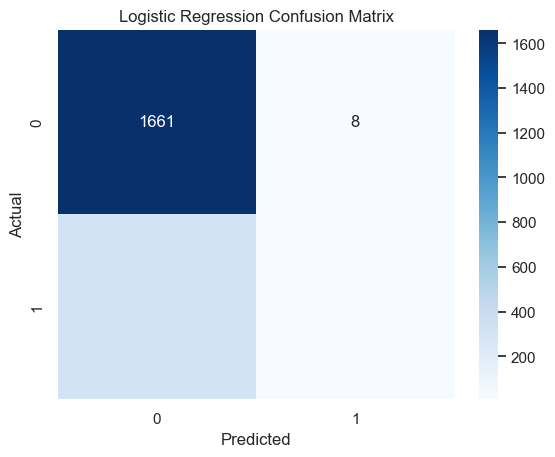

In [5]:
lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(random_state=42, max_iter=1000))
])

lr_pipeline.fit(X_train, y_train)
lr_results = evaluate_model(lr_pipeline, X_test, y_test, 'Logistic Regression')

## 5. Random Forest Classifier

--- Random Forest Performance ---
Accuracy:  0.8290
Precision: 0.4000
Recall:    0.0665
F1 Score:  0.1140

Confusion Matrix:


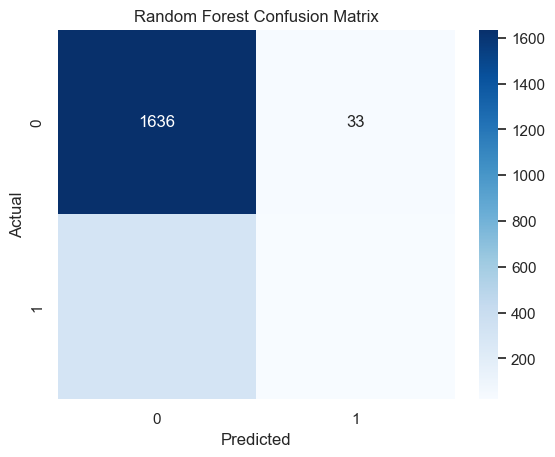

In [6]:
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42, n_estimators=100, class_weight='balanced'))
])

rf_pipeline.fit(X_train, y_train)
rf_results = evaluate_model(rf_pipeline, X_test, y_test, 'Random Forest')

## 6. Model Comparison

In [7]:
results_df = pd.DataFrame([lr_results, rf_results])
print("Model Comparison Summary:")
display(results_df)

Model Comparison Summary:


,Model,Accuracy,Precision,Recall,F1
0,Logistic Regression,0.835,0.529412,0.027190,0.051724
1,Random Forest,0.829,0.400000,0.066465,0.113990


## 7. Feature Importance (Random Forest)
Let's see which features matter most for predicting churn.

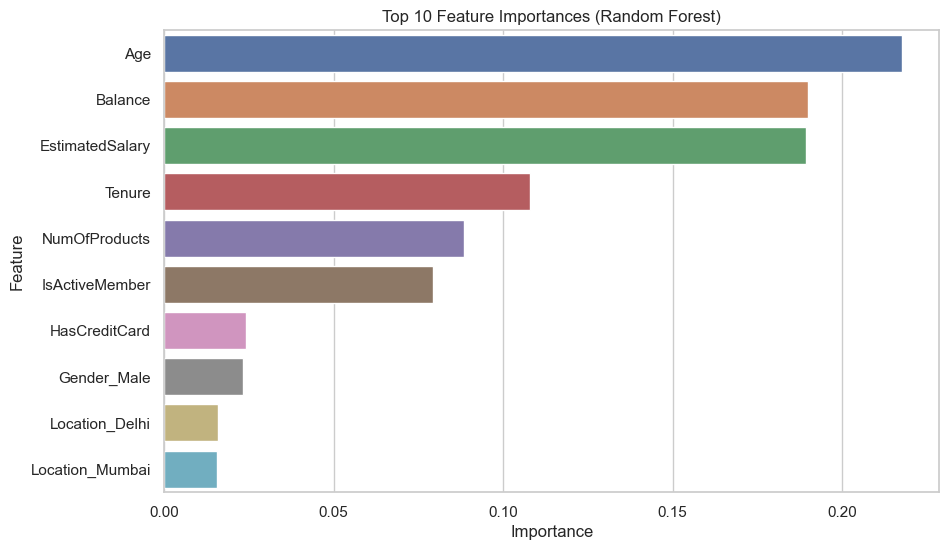

In [8]:
# Extract feature names from the preprocessor
cat_encoder = rf_pipeline.named_steps['preprocessor'].named_transformers_['cat']
cat_features = cat_encoder.get_feature_names_out(categorical_cols).tolist()
all_features = numerical_cols + cat_features

# Get importances
importances = rf_pipeline.named_steps['classifier'].feature_importances_

feat_imp_df = pd.DataFrame({
    'Feature': all_features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feat_imp_df.head(10))
plt.title('Top 10 Feature Importances (Random Forest)')
plt.show()

### Prepare output for Power BI dashboard
We will export the test set predictions along with the original features to be used in our Power BI dashboard.

In [9]:
# Transform X_test to get it back into a readable format or just append predictions
# Let's append predictions to the original test rows
export_df = X_test.copy()
export_df['Actual_Churn'] = y_test
export_df['Predicted_Churn_Prob'] = rf_pipeline.predict_proba(X_test)[:, 1]
export_df['Predicted_Churn'] = rf_pipeline.predict(X_test)

export_df.to_csv('../powerbi/powerbi_export.csv', index=False)
print("Saved predictions to powerbi/powerbi_export.csv for Dashboard building.")

Saved predictions to powerbi/powerbi_export.csv for Dashboard building.
